<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Red Neuronal (Perceptrón Multicapa) con PyTorch
## Predicción de Precios de Vehículos BMW

---

### ¿En qué se diferencia esto de la regresión lineal?

En el notebook anterior usamos **una sola capa lineal** (`nn.Linear`), lo que equivale a una regresión lineal. Eso asume que el precio tiene una relación *perfectamente lineal* con el año, motor y kilometraje.

Pero la realidad es más compleja: un BMW de alta gama con poco kilometraje puede costar desproporcionalmente más. Para capturar esas **relaciones no lineales**, usamos un **Perceptrón Multicapa (MLP)**.

### Arquitectura que vamos a construir

```
Entrada (3)  →  Capa Oculta (16 neuronas, ReLU)  →  Salida (1)
   Año
   Motor      →        [16 neuronas]              →   Precio USD
   Km
```

| Capa | Neuronas | Activación | Por qué |
|---|---|---|---|
| Entrada | 3 | — | Año, Motor, Km |
| Oculta | 16 | ReLU | Captura no linealidades |
| Salida | 1 | — | Precio en USD (valor continuo) |

> **Dataset:** `BMW sales data (2010-2024).csv`  
> Sube el archivo CSV a tu entorno Colab antes de ejecutar.

## 📦 Paso 1 — Importaciones

Exactamente las mismas librerías que en el notebook anterior. PyTorch ya viene instalado en Colab.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo : {device}')
print(f'PyTorch     : {torch.__version__}')

Dispositivo : cuda
PyTorch     : 2.10.0+cu128


## 📂 Paso 2 — Carga y Normalización de Datos

Mismo proceso que en el notebook anterior: cargamos el CSV, extraemos las 3 features y normalizamos con z-score.

$$x_{norm} = \frac{x - \mu}{\sigma}$$

> Guardamos `mu` y `sigma` porque los necesitaremos al predecir casos nuevos.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/BMW sales data (2010-2024).csv'

try:
    data = pd.read_csv(ruta_dataset)
except FileNotFoundError:
    print(f"❌ Archivo no encontrado: '{ruta_dataset}'")
    raise

X_np = data[['Year', 'Engine_Size_L', 'Mileage_KM']].values.astype(np.float32)
y_np = data['Price_USD'].values.astype(np.float32)

# Normalización z-score
mu    = X_np.mean(axis=0)
sigma = X_np.std(axis=0)
X_norm = (X_np - mu) / sigma

print(f'✅ Dataset cargado  — {len(y_np)} ejemplos')
print(f'   Media   : {mu}')
print(f'   Desv Std: {sigma}')

✅ Dataset cargado  — 50000 ejemplos
   Media   : [2.0170159e+03 3.2471800e+00 1.0030721e+05]
   Desv Std: [4.3244157e+00 1.0090684e+00 5.7940930e+04]


## 🔢 Paso 3 — Tensores PyTorch

Convertimos los arrays de NumPy a tensores y los movemos al device (GPU si está disponible).

In [5]:
X_t = torch.from_numpy(X_norm).float().to(device)          # (m, 3)
y_t = torch.from_numpy(y_np).float().unsqueeze(1).to(device)  # (m, 1)

print(f'X_t → {X_t.shape}  |  y_t → {y_t.shape}  |  device: {X_t.device}')

X_t → torch.Size([50000, 3])  |  y_t → torch.Size([50000, 1])  |  device: cuda:0


## 🧠 Paso 4 — El Perceptrón Multicapa (MLP)

### ¿Qué es un perceptrón?

Un **perceptrón** es la unidad básica de una red neuronal. Recibe entradas, las multiplica por pesos, suma un bias y aplica una función de activación:

$$\text{neurona} = f\left(\sum_{i} w_i \cdot x_i + b\right)$$

Un **MLP** apila varias capas de perceptrones. La clave está en la **función de activación ReLU** entre capas:

$$\text{ReLU}(x) = \max(0, x)$$

ReLU introduce la **no linealidad** que permite a la red aprender patrones más complejos que una regresión lineal.

### Comparación con el notebook anterior

```
Regresión lineal:   Entrada(3) → Linear(3→1) → Precio
Este MLP:           Entrada(3) → Linear(3→16) → ReLU → Linear(16→1) → Precio
```

La diferencia es la **capa oculta con ReLU** en el medio.

In [6]:
class PerceptronBMW(nn.Module):
    """
    MLP simple para regresión de precios:
      Entrada (3) → Capa oculta (16, ReLU) → Salida (1)
    """

    def __init__(self):
        super().__init__()

        # Capa 1: de las 3 features a 16 neuronas ocultas
        self.fc1 = nn.Linear(3, 16)

        # Activación: ReLU introduce la no linealidad
        self.relu = nn.ReLU()

        # Capa 2: de las 16 neuronas ocultas a 1 salida (el precio)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.fc1(x)   # Transformación lineal
        x = self.relu(x)  # Activación no lineal
        x = self.fc2(x)   # Proyección a la salida
        return x


model = PerceptronBMW().to(device)

# Contamos parámetros totales
total_params = sum(p.numel() for p in model.parameters())

print('Arquitectura:')
print(model)
print(f'\nParámetros totales: {total_params}')
print(f'  fc1: 3×16 pesos + 16 bias = {3*16 + 16}')
print(f'  fc2: 16×1 pesos +  1 bias = {16*1 + 1}')

Arquitectura:
PerceptronBMW(
  (fc1): Linear(in_features=3, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)

Parámetros totales: 81
  fc1: 3×16 pesos + 16 bias = 64
  fc2: 16×1 pesos +  1 bias = 17


## ⚙️ Paso 5 — Función de Pérdida y Optimizador

Usamos **Adam** en lugar de SGD. Adam adapta la tasa de aprendizaje para cada parámetro automáticamente, lo que lo hace más robusto y rápido de configurar que SGD.

| Optimizador | Ventaja | Cuándo usar |
|---|---|---|
| SGD | Simple, predecible | Regresión lineal básica |
| **Adam** | Converge más rápido, menos sensible al lr | Redes neuronales |

La pérdida sigue siendo **MSE** porque es un problema de regresión (predecimos un valor continuo).

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f'Pérdida    : MSELoss')
print(f'Optimizador: Adam (lr=0.001)')

Pérdida    : MSELoss
Optimizador: Adam (lr=0.001)


## 🏋️ Paso 6 — Entrenamiento

El bucle sigue el mismo patrón de 4 pasos que ya conocemos:

```
1. Forward  → predicción
2. Loss     → medir error
3. Backward → calcular gradientes (autograd)
4. Step     → actualizar pesos
```

Con una red neuronal en lugar de una regresión lineal, **la lógica del bucle no cambia en absoluto**. Eso es una de las grandes ventajas de PyTorch.

In [8]:
num_epochs  = 1000
loss_history = []

print('Entrenando el MLP...\n')
model.train()

for epoch in range(1, num_epochs + 1):

    # 1. Forward
    y_pred = model(X_t)

    # 2. Pérdida
    loss = criterion(y_pred, y_t)
    loss_history.append(loss.item())

    # 3. Backward
    optimizer.zero_grad()
    loss.backward()

    # 4. Actualizar
    optimizer.step()

    if epoch % 100 == 0:
        print(f'  Época {epoch:>5}/{num_epochs} | MSE Loss: {loss.item():,.2f}')

print('\n✅ Entrenamiento completado.')

Entrenando el MLP...

  Época   100/1000 | MSE Loss: 6,306,002,432.00
  Época   200/1000 | MSE Loss: 6,305,831,936.00
  Época   300/1000 | MSE Loss: 6,305,574,400.00
  Época   400/1000 | MSE Loss: 6,305,197,056.00
  Época   500/1000 | MSE Loss: 6,304,663,040.00
  Época   600/1000 | MSE Loss: 6,303,960,064.00
  Época   700/1000 | MSE Loss: 6,303,099,392.00
  Época   800/1000 | MSE Loss: 6,302,091,264.00
  Época   900/1000 | MSE Loss: 6,300,910,080.00
  Época  1000/1000 | MSE Loss: 6,299,574,784.00

✅ Entrenamiento completado.


## 📉 Paso 7 — Visualización de la Convergencia

Graficamos la pérdida a lo largo de las épocas. Con Adam y una capa oculta, esperamos ver una caída más pronunciada al inicio que con la regresión lineal.

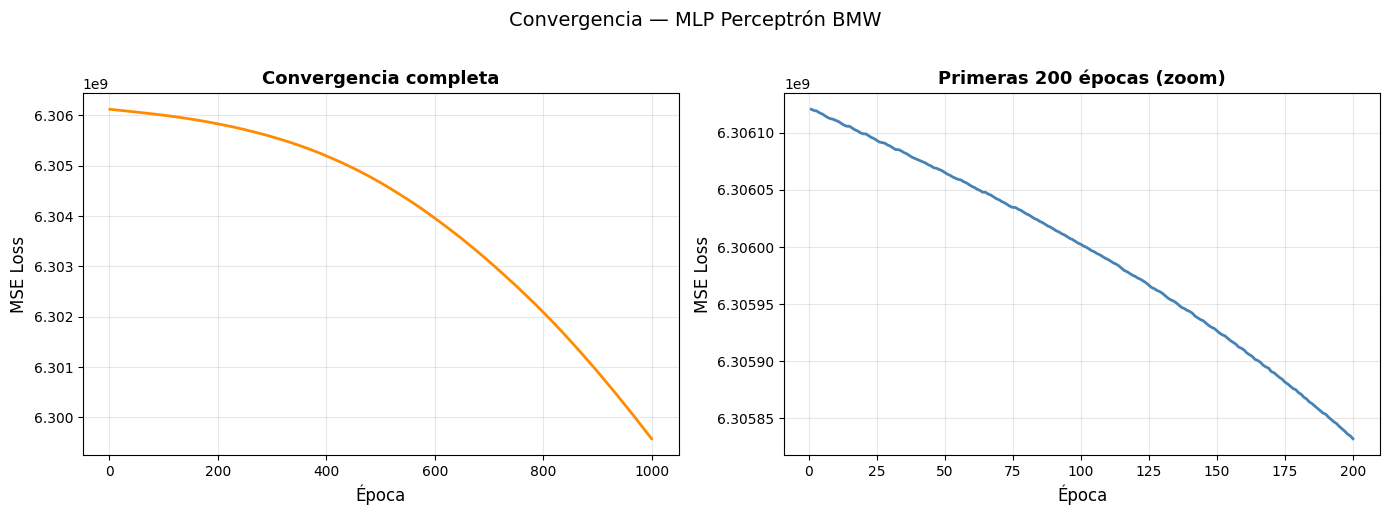

Loss inicial : 6,306,120,704.00
Loss final   : 6,299,574,784.00
Reducción    : 0.1%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergencia completa
axes[0].plot(range(1, num_epochs + 1), loss_history, lw=2, color='darkorange')
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Convergencia completa', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Zoom en las primeras 200 épocas
axes[1].plot(range(1, 201), loss_history[:200], lw=2, color='steelblue')
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('MSE Loss', fontsize=12)
axes[1].set_title('Primeras 200 épocas (zoom)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Convergencia — MLP Perceptrón BMW', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('convergencia_mlp_bmw.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Loss inicial : {loss_history[0]:,.2f}')
print(f'Loss final   : {loss_history[-1]:,.2f}')
print(f'Reducción    : {(1 - loss_history[-1]/loss_history[0])*100:.1f}%')

## 🔮 Paso 8 — Predicción de un Caso Nuevo

Mismo proceso que en el notebook de regresión lineal:

1. Normalizar con el mismo `mu` y `sigma` del entrenamiento
2. Convertir a tensor
3. Inferir con `model.eval()` y `torch.no_grad()`

In [10]:
año_test         = 2021
motor_test       = 3.0
kilometraje_test = 45_000

x_nuevo      = np.array([[año_test, motor_test, kilometraje_test]], dtype=np.float32)
x_nuevo_norm = (x_nuevo - mu) / sigma
x_tensor     = torch.from_numpy(x_nuevo_norm).float().to(device)

model.eval()
with torch.no_grad():
    precio_estimado = model(x_tensor).item()

print('=' * 52)
print('       PREDICCIÓN DE PRECIO — BMW (MLP)')
print('=' * 52)
print(f'  Año de fabricación  : {año_test}')
print(f'  Tamaño del motor    : {motor_test} L')
print(f'  Kilometraje         : {kilometraje_test:,} KM')
print('-' * 52)
print(f'  💰 PRECIO ESTIMADO  : ${precio_estimado:,.2f} USD')
print('=' * 52)

       PREDICCIÓN DE PRECIO — BMW (MLP)
  Año de fabricación  : 2021
  Tamaño del motor    : 3.0 L
  Kilometraje         : 45,000 KM
----------------------------------------------------
  💰 PRECIO ESTIMADO  : $24.02 USD


## 🧪 Bonus — Prueba con tus propios datos

Cambia los valores de abajo y vuelve a ejecutar la celda.

In [12]:
# ✏️ Modifica estos valores
mi_año         = 2015
mi_motor       = 2.5
mi_kilometraje = 70_123

# --- No modificar debajo ---
x_mi = np.array([[mi_año, mi_motor, mi_kilometraje]], dtype=np.float32)
x_mi_norm = (x_mi - mu) / sigma
x_mi_t = torch.from_numpy(x_mi_norm).float().to(device)

model.eval()
with torch.no_grad():
    mi_precio = model(x_mi_t).item()

print(f'BMW {mi_año} | {mi_motor}L | {mi_kilometraje:,} km  →  ${mi_precio:,.2f} USD')

BMW 2015 | 2.5L | 70,123 km  →  $26.28 USD


## 📋 Resumen — Regresión Lineal vs Perceptrón MLP

| Aspecto | Regresión Lineal | MLP (este notebook) |
|---|---|---|
| Capas | 1 (`Linear 3→1`) | 2 (`Linear 3→16` + `Linear 16→1`) |
| Activación | Ninguna | ReLU |
| Parámetros | 4 | 81 |
| Relaciones | Solo lineales | Lineales + no lineales |
| Optimizador | SGD | Adam |
| Épocas | 500 | 1000 |

### ¿Cuándo usar cada uno?

- **Regresión lineal** → cuando los datos tienen una relación simple y quieres un modelo interpretable.
- **MLP** → cuando sospechas relaciones no lineales o cuando la pérdida de la regresión lineal es alta.

